## 1. Load Foreign Gifts

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gifts = pd.read_csv("ForeignGifts_edu.csv")

gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## 2. Differences Between Gift Types

In [2]:
gifts.groupby("Gift Type")["Foreign Gift Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Gift Type,,,,,,,,
Contract,17274.0,6.257945e+05,3.768217e+06,-537770.0,13757.5,110000.0,366000.0,99999999.0
Monetary Gift,10936.0,5.281504e+05,2.086487e+06,1.0,250.0,50000.0,400000.0,48842186.0
Real Estate,11.0,1.335265e+06,1.412071e+06,39456.0,370574.5,667555.0,2121736.0,4312000.0


In [3]:
gifts.groupby("Gift Type")["Foreign Gift Amount"].median()

Gift Type
Contract         110000.0
Monetary Gift     50000.0
Real Estate      667555.0
Name: Foreign Gift Amount, dtype: float64

There are three types of gifts ad there are vast differences between them. Contracts, the first type, are the most common class, with 17,274 records, followed by Monetary Gifts with 10,936 records. Real Estate is very uncommon, with only 11 records. Contracts and Monetary Gifts both vary greatly in dollar amount, but Contracts tend to be larger than Monetary Gifts. The median Contract is about $110,000, compared with about $50,000 for a Monetary Gift. Real Estate has the highest typical dollar value, with a median of about $667,555, although there are too few Real Estate records to compare it as confidently with the other two classes. The large differences between the means and medians also show that the gift amounts are right-skewed. A small number of very large gifts increase the averages substantially.

## 3.1 Which country gives the most money in total?

In [4]:
country_total = gifts.groupby("Country of Giftor")["Foreign Gift Amount"].sum()

country_total.sort_values(ascending=False).head(1)

Country of Giftor
QATAR    2706240869
Name: Foreign Gift Amount, dtype: int64

Qatar gives the most money.

## 3.2 Which country initiates the most gifts by count?

In [5]:
country_count = gifts.groupby("Country of Giftor")["Foreign Gift Amount"].count()

country_count.sort_values(ascending=False).head(1)

Country of Giftor
ENGLAND    3655
Name: Foreign Gift Amount, dtype: int64

England gives the most gifts.

## 3.3 Which country gives the largest gifts on average?

In [6]:
country_average = gifts.groupby("Country of Giftor")["Foreign Gift Amount"].mean()

country_average.sort_values(ascending=False).head(1)

Country of Giftor
BERMUDA    7.688837e+06
Name: Foreign Gift Amount, dtype: float64

Bermuda gives the largest gift on average.

## 3.4 Which institution receives the most money in total?

In [7]:
institution_total = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

institution_total.head(1)

Institution Name
Carnegie Mellon University    1477922504
Name: Foreign Gift Amount, dtype: int64

Carnegie Mellon University gets the most money.

## 3.5 Which institution receives the greatest number of gifts by count?

In [8]:
institution_count = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
)

institution_count.head(1)

Institution Name
University of California, Los Angeles    3916
Name: Foreign Gift Amount, dtype: int64

UCLA gets the most gifts.

## 3.6 What is the average amount each university receives? What is the median amount? If they are different, why?

Mean: $52,202,878.97
Median: $6,486,791.50


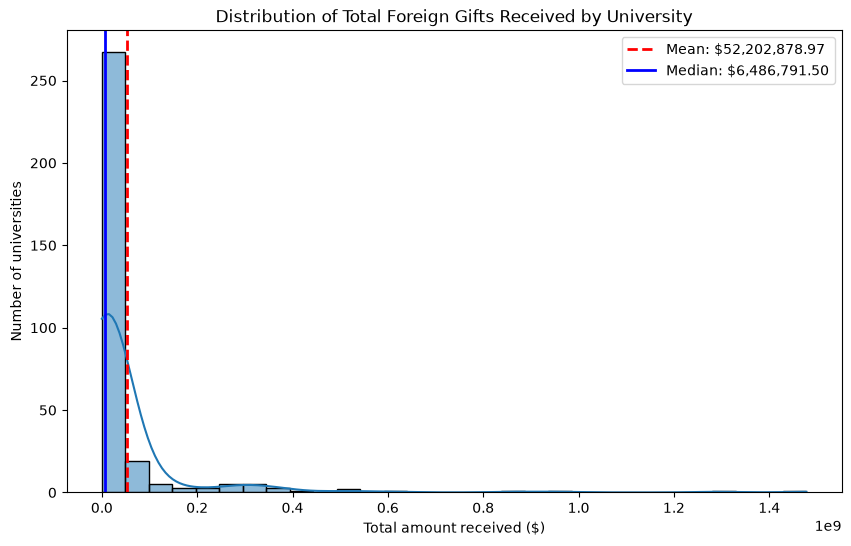

In [9]:
university_totals = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
)

mean_amount = university_totals.mean()
median_amount = university_totals.median()

print(f"Mean: ${mean_amount:,.2f}")
print(f"Median: ${median_amount:,.2f}")

plt.figure(figsize=(10, 6))

sns.histplot(university_totals, bins=30, kde=True)

plt.axvline(
    mean_amount,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_amount:,.2f}"
)

plt.axvline(
    median_amount,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Median: ${median_amount:,.2f}"
)

plt.title("Distribution of Total Foreign Gifts Received by University")
plt.xlabel("Total amount received ($)")
plt.ylabel("Number of universities")
plt.legend()
plt.show()

The average amount received by an institution is approximately $52.2 million, while the median is approximately $6.49 million.

The average is much larger than the median because the distribution is right-skewed. A relatively small number of universities receive extremely large amounts of foreign money. These very large values pull the mean upward, while the median is less affected by extreme values. Therefore, the median better represents the typical university, while the mean is influenced by these unusually large amounts.

## 3.7 What is the largest flow of a single country to a single institution?

In [10]:
country_institution = pd.crosstab(
    gifts["Country of Giftor"],
    gifts["Institution Name"],
    values=gifts["Foreign Gift Amount"],
    aggfunc="sum"
).fillna(0)

country_institution

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AMERICAN SAMOA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ANGOLA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ANTIGUA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARGENTINA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2858666.0,0.0,0.0
WALES,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,720000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YEMEN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
largest_flow = (
    country_institution
    .stack()
    .sort_values(ascending=False)
)

largest_flow.head(1)

Country of Giftor  Institution Name  
QATAR              Cornell University    1.018473e+09
dtype: float64

The largest flow from a single country to a single institution is from Qatar to Cornell University, approximately $1.02 billion.

## 3.8 Which are the top giftors to US academic institutions?

In [12]:
import plotly.graph_objects as go

giftor = "Country of Giftor"
recipi = "Institution Name"
flow = "Foreign Gift Amount"
N = 25

flows = (
    gifts.groupby([giftor, recipi])[flow]
    .sum()
    .nlargest(N)
    .reset_index()
)

labels = flows[giftor].tolist() + flows[recipi].tolist()
labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=labels
        ),
        link=dict(
            source=flows[giftor].map(labels.index),
            target=flows[recipi].map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [13]:
top_giftors = (
    gifts.dropna(subset=["Giftor Name"])
    .groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

top_giftors.head(10)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64